# Deep Reinforcement Learning: DQN for MountainCar with Custom Reward Shaping

This portfolio notebook develops a **Deep Q-Network (DQN)** agent for `MountainCar-v0`.


The notebook keeps the original custom reward and neural-network design while making the complete DQN implementation visible and self-contained for Google Colab.

The notebook covers:

- the MountainCar state and action spaces,
- why the car must first build momentum,
- the supplied custom reward function,
- Q-learning versus DQN,
- the `2 → 32 → 3` Q-network,
- epsilon-greedy exploration,
- experience replay,
- online and target networks,
- the DQN target and TD error,
- a complete numerical DQN update,
- 300-episode training,
- reward, episode-length, Q-value, epsilon, TD-error, and loss plots,
- goal-reaching statistics,
- random-policy comparison,
- learned policy visualization over the state space,
- model saving/loading,
- and an MP4 evaluation video.

## 1. MountainCar problem

`MountainCar-v0` contains a car trapped in a valley.

The car's engine is not strong enough to drive directly up the right hill from the starting position. The agent must first move away from the goal, gain momentum, and then use that momentum to climb the hill.

The state is

$$
\boxed{
S_t=
[x_t,\dot{x}_t]
}
$$

where:

| Index | Variable | Meaning |
|---:|---|---|
| 0 | $x_t$ | car position |
| 1 | $\dot{x}_t$ | car velocity |

The approximate state ranges are

$$
-1.2\leq x_t\leq0.6
$$

and

$$
-0.07\leq\dot{x}_t\leq0.07.
$$

## 2. Action space

MountainCar has three discrete actions:

$$
\boxed{
A_t\in\{0,1,2\}
}
$$

| Action | Meaning |
|---:|---|
| 0 | accelerate left |
| 1 | no acceleration |
| 2 | accelerate right |

The goal is reached when the car position reaches approximately

$$
\boxed{x\geq0.5}.
$$

## 3. Why momentum matters

If the agent always pushes right, the engine is usually too weak to climb directly to the goal.

A successful strategy often looks like

$$
\boxed{
\text{move left}
\rightarrow
\text{gain momentum}
\rightarrow
\text{move right}
\rightarrow
\text{reach the goal}
}
$$

This makes MountainCar a useful reinforcement-learning example because an action that temporarily moves the car **away from the goal** can be necessary for long-term success.

## 4. Default reward versus the supplied custom reward

The standard MountainCar environment normally gives a reward of

$$
-1
$$

for every time step until the episode terminates.

Your supplied wrapper replaces that reward with:

```python
vel = abs(state[1]) * 1000

if vel < 0.1:
    vel = 0.1

reward = (state[0] - 0.5) / vel

if state[0] >= 0.5:
    reward = 100.0
```

The same reward logic is preserved in this notebook.

## 5. Understanding the custom reward

Let position be $x_t$ and velocity be $\dot{x}_t$.

First,

$$
v_{\text{scaled}}
=
1000|\dot{x}_t|.
$$

To avoid division by a number too close to zero:

$$
\boxed{
v_{\text{safe}}
=
\max(1000|\dot{x}_t|,0.1)
}
$$

Before reaching the goal:

$$
\boxed{
R_{t+1}
=
\frac{x_t-0.5}{v_{\text{safe}}}
}
$$

When the goal is reached:

$$
\boxed{
R_{t+1}=100.
}
$$

Because $x_t<0.5$ before the goal, the ordinary shaped reward is negative.

The reward becomes less negative when:

- the car is closer to the goal,
- or the magnitude of its velocity is larger.

Therefore, this shaping encourages the car to build momentum instead of remaining nearly stationary.

A very small velocity can produce a relatively large negative reward because the denominator is forced to `0.1`.

## 6. Example of the custom reward

Suppose

$$
x_t=-0.40
$$

and

$$
\dot{x}_t=0.020.
$$

Then

$$
v_{\text{scaled}}
=
|0.020|\times1000
=
20.
$$

Therefore,

$$
R_{t+1}
=
\frac{-0.40-0.50}{20}
$$

$$
=
\frac{-0.90}{20}
$$

$$
\boxed{
R_{t+1}=-0.045.
}
$$

If the car reaches

$$
x_t\geq0.5,
$$

the reward becomes

$$
\boxed{100}.
$$

## 7. Why DQN instead of a Q-table?

MountainCar has only two state variables, but both are continuous.

A tabular Q-learning method would require discretizing position and velocity into bins.

DQN instead learns

$$
\boxed{
Q(s,a;\theta)\approx Q^*(s,a)
}
$$

with a neural network.

For every state, the network outputs three values:

$$
\boxed{
Q(S_t,\cdot;\theta)
=
[
Q(S_t,0),
Q(S_t,1),
Q(S_t,2)
]
}
$$

The greedy action is

$$
\boxed{
A_t=
\arg\max_a Q(S_t,a;\theta).
}
$$

## 8. Q-network architecture

The supplied architecture is retained:

$$
\boxed{
2\rightarrow32\rightarrow3
}
$$

The hidden layer uses ReLU:

$$
h=
\operatorname{ReLU}(W_1S+b_1)
$$

and the output layer is linear:

$$
\boxed{
Q(S,\cdot;\theta)=W_2h+b_2.
}
$$

The three output neurons correspond to:

$$
[
Q(\text{left}),
Q(\text{neutral}),
Q(\text{right})
].
$$

The supplied Adam learning rate is

$$
\boxed{0.001}.
$$

## 9. DQN target

DQN maintains:

- an **online network** $Q(s,a;\theta)$,
- a **target network** $Q(s,a;\theta^-)$.

For transition

$$
(S_t,A_t,R_{t+1},S_{t+1},D_t),
$$

the target is

$$
\boxed{
Y_t
=
R_{t+1}
+
\gamma(1-D_t)
\max_{a'}
Q(S_{t+1},a';\theta^-)
}
$$

where

$$
D_t=
\begin{cases}
1,&\text{terminal transition}\\
0,&\text{otherwise}.
\end{cases}
$$

The current prediction is

$$
\boxed{
\hat Q_t
=
Q(S_t,A_t;\theta)
}
$$

and the TD error is

$$
\boxed{
\delta_t
=
Y_t-\hat Q_t.
}
$$

## 10. Complete one-step DQN calculation

Suppose the current state is

$$
S_t=[-0.40,\ 0.020].
$$

The custom reward from the previous example is

$$
R_{t+1}=-0.045.
$$

Assume the online network predicts

$$
Q(S_t,\cdot;\theta)
=
[1.20,\ 1.50,\ 0.90].
$$

If the agent exploits:

$$
A_t
=
\arg\max[1.20,1.50,0.90]
=
1.
$$

Therefore,

$$
\boxed{
\hat Q_t=1.50.
}
$$

Suppose the target network predicts at the next state

$$
Q(S_{t+1},\cdot;\theta^-)
=
[1.40,\ 1.10,\ 1.80].
$$

Thus,

$$
\max_{a'}
Q(S_{t+1},a';\theta^-)
=
1.80.
$$

Using

$$
\gamma=0.99,
$$

the target is

$$
Y_t
=
-0.045
+
0.99(1.80)
$$

$$
=
-0.045+1.782
$$

$$
\boxed{
Y_t=1.737.
}
$$

The TD error is

$$
\delta_t
=
1.737-1.50
$$

$$
\boxed{
\delta_t=0.237.
}
$$

If the transition reaches the goal, the terminal reward is $100$ and no next-state value is added:

$$
\boxed{
Y_t=100.
}
$$

## 11. Experience replay

DQN stores past experience in replay memory:

$$
\boxed{
\mathcal D
=
\{
(S_t,A_t,R_{t+1},S_{t+1},D_t)
\}.
}
$$

A random mini-batch is sampled during learning.

The supplied settings use:

$$
\boxed{
|\mathcal D|_{\max}=100{,}000
}
$$

and

$$
\boxed{
\text{batch size}=64.
}
$$

Replay allows the network to reuse old transitions and reduces the strong correlation between consecutive states.

## 12. Target network

The online network changes after every gradient update.

If it were also used to construct every target, the target itself would change very rapidly.

DQN therefore keeps a separate target network.

Every 1,000 environment steps:

$$
\boxed{
\theta^-\leftarrow\theta.
}
$$

## 13. Epsilon-greedy exploration

The agent follows

$$
A_t=
\begin{cases}
\text{random action},&\text{with probability }\epsilon\\
\arg\max_aQ(S_t,a;\theta),&\text{with probability }1-\epsilon.
\end{cases}
$$

The supplied settings are:

$$
\epsilon_0=1.0
$$

$$
\epsilon_{\min}=0.01
$$

$$
\text{decay}=1.05.
$$

This notebook implements the original decay parameter as

$$
\boxed{
\epsilon
\leftarrow
\max
\left(
0.01,
\frac{\epsilon}{1.05}
\right).
}
$$

## 14. Colab setup

In [1]:
%pip -q install "gymnasium[classic-control]" imageio imageio-ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 84.7 MB/s eta 0:00:00


In [2]:
import os
import random
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v2 as imageio

import gymnasium as gym
import tensorflow as tf

from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

from IPython.display import display, Video

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

np.set_printoptions(
    precision=4,
    suppress=True,
)

pd.set_option(
    "display.precision",
    4,
)

print(
    "TensorFlow:",
    tf.__version__,
)

print(
    "Gymnasium:",
    gym.__version__,
)

TensorFlow: 2.21.0
Gymnasium: 1.3.0


## 15. Custom MountainCar environment wrapper

In [3]:
class MountainCarEnvironment(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
        self.state = None

    def calculate_reward(self):
        velocity_term = (
            abs(self.state[1])
            * 1_000
        )

        if velocity_term < 0.1:
            velocity_term = 0.1

        reward = (
            self.state[0] - 0.5
        ) / velocity_term

        if self.state[0] >= 0.5:
            reward = 100.0

        return float(reward)

    def reset(
        self,
        *,
        seed=None,
        options=None,
    ):
        state, info = self.env.reset(
            seed=seed,
            options=options,
        )

        self.state = np.asarray(
            state,
            dtype=np.float32,
        )

        return (
            self.state.copy(),
            info,
        )

    def step(self, action):
        (
            state,
            original_reward,
            terminated,
            truncated,
            info,
        ) = self.env.step(
            int(action)
        )

        self.state = np.asarray(
            state,
            dtype=np.float32,
        )

        custom_reward = (
            self.calculate_reward()
        )

        info = dict(info)

        info["original_reward"] = (
            float(original_reward)
        )

        info["goal_reached"] = bool(
            self.state[0] >= 0.5
        )

        return (
            self.state.copy(),
            custom_reward,
            bool(terminated),
            bool(truncated),
            info,
        )

## 16. Inspect the environment and reward

In [4]:
env = MountainCarEnvironment(
    gym.make("MountainCar-v0")
)

state, info = env.reset(
    seed=SEED
)

print("Initial state:", state)
print(
    "Observation space:",
    env.observation_space,
)
print(
    "Action space:",
    env.action_space,
)

print(
    "Custom reward at initial state:",
    env.calculate_reward(),
)

env.close()

Initial state: [-0.4452  0.    ]
Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action space: Discrete(3)
Custom reward at initial state: -9.45208740234375


## 17. Build the Q-network

In [5]:
def build_q_network():
    state_input = Input(
        shape=(2,),
        name="state",
    )

    x = Dense(
        32,
        activation="relu",
        name="hidden_1",
    )(state_input)

    q_values = Dense(
        3,
        activation="linear",
        name="q_values",
    )(x)

    return Model(
        inputs=state_input,
        outputs=q_values,
        name="MountainCar_DQN",
    )


q_network_demo = (
    build_q_network()
)

q_network_demo.summary()

Model: "MountainCar_DQN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ state (InputLayer)              │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_values (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 195 (780.00 B)

 Trainable params: 195 (780.00 B)

 Non-trainable params: 0 (0.00 B)

## 18. Replay buffer

In [6]:
class ReplayBuffer:
    def __init__(
        self,
        capacity=100_000,
    ):
        self.buffer = deque(
            maxlen=capacity
        )

    def add(
        self,
        state,
        action,
        reward,
        next_state,
        done,
    ):
        self.buffer.append(
            (
                np.asarray(
                    state,
                    dtype=np.float32,
                ),
                int(action),
                float(reward),
                np.asarray(
                    next_state,
                    dtype=np.float32,
                ),
                float(done),
            )
        )

    def sample(
        self,
        batch_size,
    ):
        batch = random.sample(
            self.buffer,
            batch_size,
        )

        (
            states,
            actions,
            rewards,
            next_states,
            dones,
        ) = map(
            np.array,
            zip(*batch),
        )

        return (
            states.astype(
                np.float32
            ),
            actions.astype(
                np.int32
            ),
            rewards.astype(
                np.float32
            ),
            next_states.astype(
                np.float32
            ),
            dones.astype(
                np.float32
            ),
        )

    def __len__(self):
        return len(
            self.buffer
        )

## 19. DQN agent

Your original code used:

```text
learn_after_steps = 4
batch_size = 64
```

A random batch of 64 cannot be sampled from only four transitions unless the hidden library uses a special sampling rule.

For this self-contained portfolio implementation, gradient updates begin after

$$
\boxed{1{,}000\text{ transitions}}
$$

have been collected.

This produces a more diverse initial replay buffer while keeping all other main hyperparameters from your code.

In [7]:
class DQNAgent:
    def __init__(
        self,
        learning_rate=0.001,
        gamma=0.99,
        replay_size=100_000,
        min_replay_size=1_000,
        epsilon=1.0,
        min_epsilon=0.01,
        epsilon_decay=1.05,
        target_update_steps=1_000,
        gradient_clip_norm=10.0,
    ):
        self.gamma = gamma

        self.epsilon = epsilon
        self.min_epsilon = (
            min_epsilon
        )
        self.epsilon_decay = (
            epsilon_decay
        )

        self.min_replay_size = (
            min_replay_size
        )

        self.target_update_steps = (
            target_update_steps
        )

        self.gradient_clip_norm = (
            gradient_clip_norm
        )

        self.replay = ReplayBuffer(
            replay_size
        )

        self.q_network = (
            build_q_network()
        )

        self.target_network = (
            build_q_network()
        )

        self.target_network.set_weights(
            self.q_network.get_weights()
        )

        self.optimizer = Adam(
            learning_rate=learning_rate
        )

        self.loss_fn = (
            tf.keras.losses.Huber()
        )

        self.environment_steps = 0
        self.gradient_steps = 0

    def select_action(
        self,
        state,
        training=True,
    ):
        if (
            training
            and np.random.random()
            < self.epsilon
        ):
            return np.random.randint(
                3
            )

        state_tensor = (
            tf.convert_to_tensor(
                np.asarray(
                    state,
                    dtype=np.float32,
                )[None, :],
                dtype=tf.float32,
            )
        )

        q_values = self.q_network(
            state_tensor,
            training=False,
        )

        return int(
            tf.argmax(
                q_values[0]
            ).numpy()
        )

    def remember(
        self,
        state,
        action,
        reward,
        next_state,
        done,
    ):
        self.replay.add(
            state,
            action,
            reward,
            next_state,
            done,
        )

    def train_step(
        self,
        batch_size=64,
    ):
        if len(self.replay) < max(
            self.min_replay_size,
            batch_size,
        ):
            return None

        (
            states,
            actions,
            rewards,
            next_states,
            dones,
        ) = self.replay.sample(
            batch_size
        )

        states_t = (
            tf.convert_to_tensor(
                states,
                dtype=tf.float32,
            )
        )

        next_states_t = (
            tf.convert_to_tensor(
                next_states,
                dtype=tf.float32,
            )
        )

        rewards_t = (
            tf.convert_to_tensor(
                rewards,
                dtype=tf.float32,
            )
        )

        dones_t = (
            tf.convert_to_tensor(
                dones,
                dtype=tf.float32,
            )
        )

        actions_t = (
            tf.convert_to_tensor(
                actions,
                dtype=tf.int32,
            )
        )

        next_q_values = (
            self.target_network(
                next_states_t,
                training=False,
            )
        )

        max_next_q = tf.reduce_max(
            next_q_values,
            axis=1,
        )

        targets = (
            rewards_t
            + self.gamma
            * (1.0 - dones_t)
            * max_next_q
        )

        with tf.GradientTape() as tape:
            all_q_values = (
                self.q_network(
                    states_t,
                    training=True,
                )
            )

            indices = tf.stack(
                [
                    tf.range(
                        batch_size,
                        dtype=tf.int32,
                    ),
                    actions_t,
                ],
                axis=1,
            )

            predicted_q = tf.gather_nd(
                all_q_values,
                indices,
            )

            loss = self.loss_fn(
                targets,
                predicted_q,
            )

        gradients = tape.gradient(
            loss,
            self.q_network.trainable_variables,
        )

        (
            gradients,
            gradient_norm,
        ) = tf.clip_by_global_norm(
            gradients,
            self.gradient_clip_norm,
        )

        self.optimizer.apply_gradients(
            zip(
                gradients,
                self.q_network.trainable_variables,
            )
        )

        self.gradient_steps += 1

        td_error = tf.reduce_mean(
            tf.abs(
                targets
                - predicted_q
            )
        )

        average_q = tf.reduce_mean(
            predicted_q
        )

        return {
            "loss": float(
                loss.numpy()
            ),
            "td_error": float(
                td_error.numpy()
            ),
            "average_q": float(
                average_q.numpy()
            ),
            "gradient_norm": float(
                gradient_norm.numpy()
            ),
        }

    def update_target_if_needed(
        self,
    ):
        if (
            self.environment_steps > 0
            and self.environment_steps
            % self.target_update_steps
            == 0
        ):
            self.target_network.set_weights(
                self.q_network.get_weights()
            )

    def decay_epsilon(
        self,
    ):
        self.epsilon = max(
            self.min_epsilon,
            self.epsilon
            / self.epsilon_decay,
        )

    def save(
        self,
        path,
    ):
        os.makedirs(
            path,
            exist_ok=True,
        )

        self.q_network.save_weights(
            os.path.join(
                path,
                "q_network.weights.h5",
            )
        )

        self.target_network.save_weights(
            os.path.join(
                path,
                "target_network.weights.h5",
            )
        )

        np.savez(
            os.path.join(
                path,
                "agent_state.npz",
            ),
            epsilon=self.epsilon,
            environment_steps=(
                self.environment_steps
            ),
            gradient_steps=(
                self.gradient_steps
            ),
        )

    def load(
        self,
        path,
    ):
        dummy = np.zeros(
            (1, 2),
            dtype=np.float32,
        )

        self.q_network(dummy)
        self.target_network(dummy)

        self.q_network.load_weights(
            os.path.join(
                path,
                "q_network.weights.h5",
            )
        )

        target_path = os.path.join(
            path,
            "target_network.weights.h5",
        )

        if os.path.exists(
            target_path
        ):
            self.target_network.load_weights(
                target_path
            )
        else:
            self.target_network.set_weights(
                self.q_network.get_weights()
            )

        state_path = os.path.join(
            path,
            "agent_state.npz",
        )

        if os.path.exists(
            state_path
        ):
            data = np.load(
                state_path
            )

            self.epsilon = float(
                data["epsilon"]
            )

            self.environment_steps = int(
                data[
                    "environment_steps"
                ]
            )

            self.gradient_steps = int(
                data[
                    "gradient_steps"
                ]
            )

## 20. Training configuration

The supplied experiment trains for

$$
\boxed{300\text{ episodes}}
$$

and saves the agent every 10 episodes.

Those settings are preserved.

`QUICK_RUN=True` can be used to test the notebook before running the full experiment.

In [8]:
QUICK_RUN = False

NUM_EPISODES = (
    50
    if QUICK_RUN
    else 300
)

BATCH_SIZE = 64

AGENT_PATH = (
    "mountain_car_agent"
)

BEST_AGENT_PATH = (
    "mountain_car_best_agent"
)

agent = DQNAgent(
    learning_rate=0.001,
    gamma=0.99,
    replay_size=100_000,
    min_replay_size=1_000,
    epsilon=1.0,
    min_epsilon=0.01,
    epsilon_decay=1.05,
    target_update_steps=1_000,
    gradient_clip_norm=10.0,
)

train_env = (
    MountainCarEnvironment(
        gym.make(
            "MountainCar-v0"
        )
    )
)

## 21. Train the DQN

In [9]:
history = {
    "episode": [],
    "total_reward": [],
    "episode_length": [],
    "epsilon": [],
    "average_q": [],
    "td_error": [],
    "loss": [],
    "goal_reached": [],
    "max_position": [],
}

best_success_rate = -1.0

for episode in range(
    NUM_EPISODES
):
    state, info = train_env.reset(
        seed=SEED + episode
    )

    done = False

    total_reward = 0.0
    episode_length = 0
    goal_reached = False
    max_position = state[0]

    q_values = []
    td_errors = []
    losses = []

    while not done:
        action = agent.select_action(
            state,
            training=True,
        )

        (
            next_state,
            reward,
            terminated,
            truncated,
            info,
        ) = train_env.step(
            action
        )

        done = (
            terminated
            or truncated
        )

        agent.remember(
            state,
            action,
            reward,
            next_state,
            done,
        )

        agent.environment_steps += 1

        result = agent.train_step(
            batch_size=BATCH_SIZE
        )

        if result is not None:
            q_values.append(
                result["average_q"]
            )

            td_errors.append(
                result["td_error"]
            )

            losses.append(
                result["loss"]
            )

        agent.update_target_if_needed()

        state = next_state

        total_reward += reward
        episode_length += 1

        max_position = max(
            max_position,
            state[0],
        )

        if info.get(
            "goal_reached",
            False,
        ):
            goal_reached = True

    history["episode"].append(
        episode + 1
    )

    history["total_reward"].append(
        total_reward
    )

    history["episode_length"].append(
        episode_length
    )

    history["epsilon"].append(
        agent.epsilon
    )

    history["average_q"].append(
        np.mean(q_values)
        if q_values
        else np.nan
    )

    history["td_error"].append(
        np.mean(td_errors)
        if td_errors
        else np.nan
    )

    history["loss"].append(
        np.mean(losses)
        if losses
        else np.nan
    )

    history["goal_reached"].append(
        int(goal_reached)
    )

    history["max_position"].append(
        max_position
    )

    agent.decay_epsilon()

    # Preserve the original idea:
    # save every 10 episodes.
    if (
        (episode + 1)
        % 10
        == 0
    ):
        agent.save(
            AGENT_PATH
        )

        recent_success = np.mean(
            history[
                "goal_reached"
            ][-20:]
        )

        if (
            recent_success
            > best_success_rate
        ):
            best_success_rate = (
                recent_success
            )

            agent.save(
                BEST_AGENT_PATH
            )

        print(
            f"Episode {episode+1:3d} | "
            f"Reward: {total_reward:9.3f} | "
            f"Length: {episode_length:3d} | "
            f"Goal: {goal_reached} | "
            f"Max x: {max_position:.3f} | "
            f"Epsilon: {agent.epsilon:.4f}"
        )

train_env.close()

agent.save(
    AGENT_PATH
)

Episode  10 | Reward:   -80.746 | Length: 200 | Goal: False | Max x: -0.327 | Epsilon: 0.6139
Episode  20 | Reward:   -47.790 | Length: 200 | Goal: False | Max x: 0.051 | Epsilon: 0.3769
Episode  30 | Reward:   -73.417 | Length: 200 | Goal: False | Max x: 0.190 | Epsilon: 0.2314
Episode  40 | Reward:    82.069 | Length: 144 | Goal: True | Max x: 0.513 | Epsilon: 0.1420
Episode  50 | Reward:    80.409 | Length: 146 | Goal: True | Max x: 0.532 | Epsilon: 0.0872
Episode  60 | Reward:    92.642 | Length:  87 | Goal: True | Max x: 0.519 | Epsilon: 0.0535
Episode  70 | Reward:    79.782 | Length: 138 | Goal: True | Max x: 0.501 | Epsilon: 0.0329
Episode  80 | Reward:    59.728 | Length: 149 | Goal: True | Max x: 0.514 | Epsilon: 0.0202
Episode  90 | Reward:    70.328 | Length: 146 | Goal: True | Max x: 0.537 | Epsilon: 0.0124
Episode 100 | Reward:    69.659 | Length: 150 | Goal: True | Max x: 0.506 | Epsilon: 0.0100
Episode 110 | Reward:    67.746 | Length: 139 | Goal: True | Max x: 0.506 | 

In [10]:
history_df = pd.DataFrame(
    history
)

history_df.to_csv(
    "mountain_car_dqn_training_history.csv",
    index=False,
)

history_df.tail()

,episode,total_reward,episode_length,epsilon,average_q,td_error,loss,goal_reached,max_position
295,296,74.1562,134,0.01,0.6653,0.7108,0.5480,1,0.5157
296,297,71.3824,147,0.01,0.6817,0.7973,0.6366,1,0.5004
297,298,80.0876,139,0.01,0.6351,0.7624,0.6055,1,0.5006
298,299,66.6668,163,0.01,0.7050,0.7225,0.5658,1,0.5367
299,300,71.2951,147,0.01,0.6947,0.8195,0.6410,1,0.5171


## 22. Custom reward versus episode

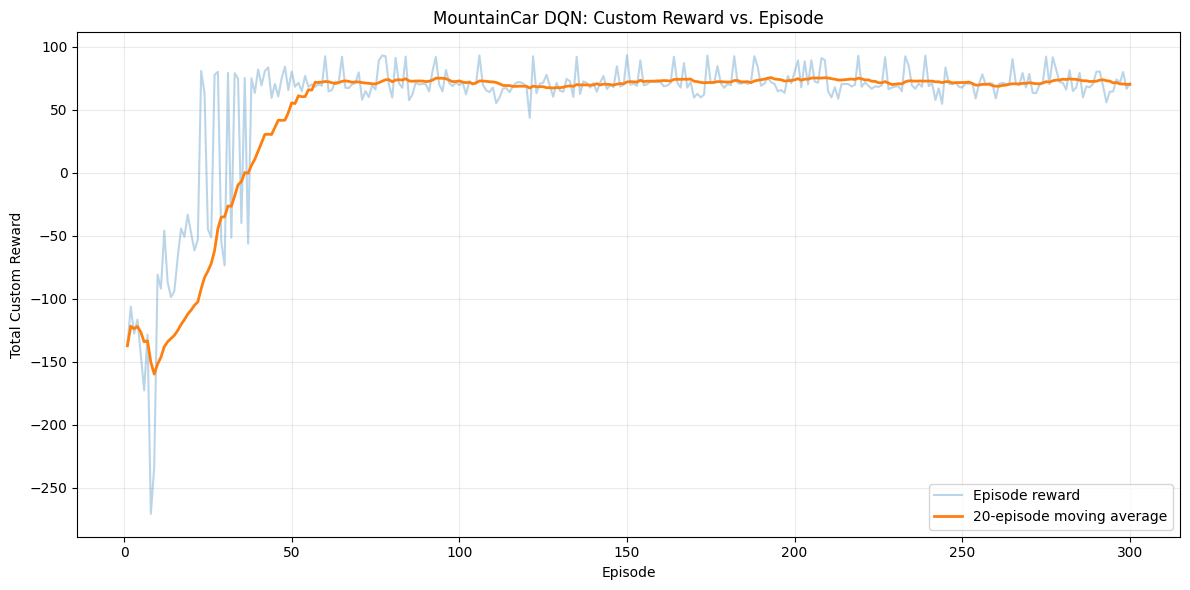

In [11]:
WINDOW = 20

reward_ma = (
    history_df[
        "total_reward"
    ]
    .rolling(
        WINDOW,
        min_periods=1,
    )
    .mean()
)

plt.figure(
    figsize=(12, 6)
)

plt.plot(
    history_df["episode"],
    history_df["total_reward"],
    alpha=0.30,
    label="Episode reward",
)

plt.plot(
    history_df["episode"],
    reward_ma,
    linewidth=2,
    label="20-episode moving average",
)

plt.xlabel("Episode")
plt.ylabel("Total Custom Reward")
plt.title(
    "MountainCar DQN: "
    "Custom Reward vs. Episode"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 23. Episode length

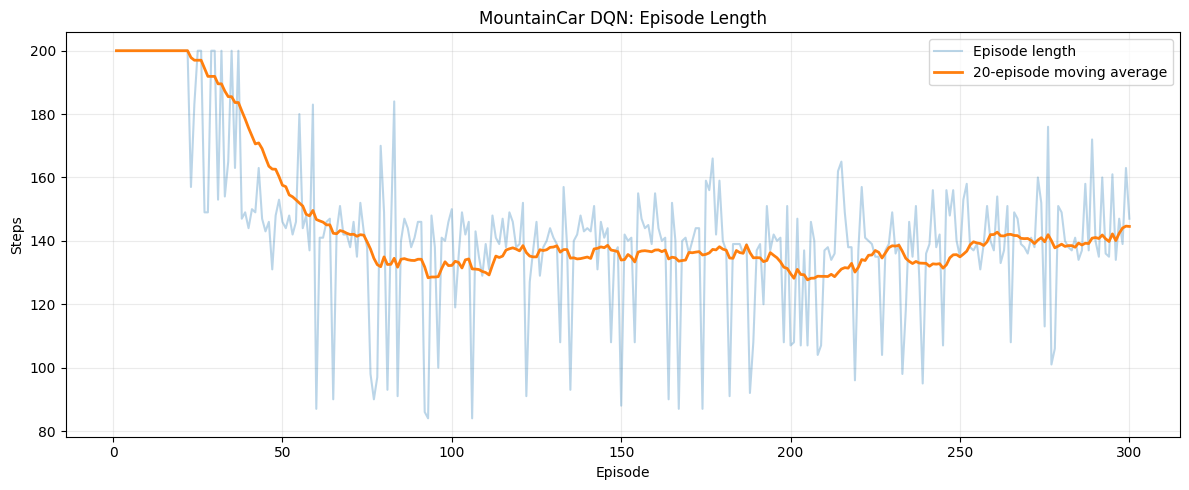

In [12]:
length_ma = (
    history_df[
        "episode_length"
    ]
    .rolling(
        WINDOW,
        min_periods=1,
    )
    .mean()
)

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    history_df["episode"],
    history_df[
        "episode_length"
    ],
    alpha=0.30,
    label="Episode length",
)

plt.plot(
    history_df["episode"],
    length_ma,
    linewidth=2,
    label="20-episode moving average",
)

plt.xlabel("Episode")
plt.ylabel("Steps")
plt.title(
    "MountainCar DQN: "
    "Episode Length"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 24. Maximum position reached

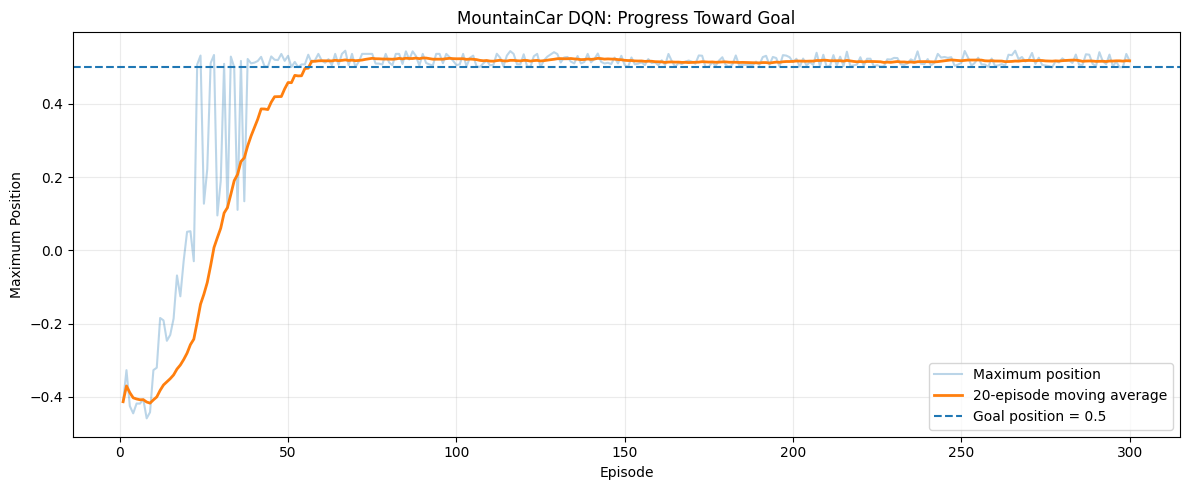

In [13]:
max_position_ma = (
    history_df[
        "max_position"
    ]
    .rolling(
        WINDOW,
        min_periods=1,
    )
    .mean()
)

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    history_df["episode"],
    history_df[
        "max_position"
    ],
    alpha=0.30,
    label="Maximum position",
)

plt.plot(
    history_df["episode"],
    max_position_ma,
    linewidth=2,
    label="20-episode moving average",
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Goal position = 0.5",
)

plt.xlabel("Episode")
plt.ylabel("Maximum Position")
plt.title(
    "MountainCar DQN: "
    "Progress Toward Goal"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 25. Rolling goal-reaching rate

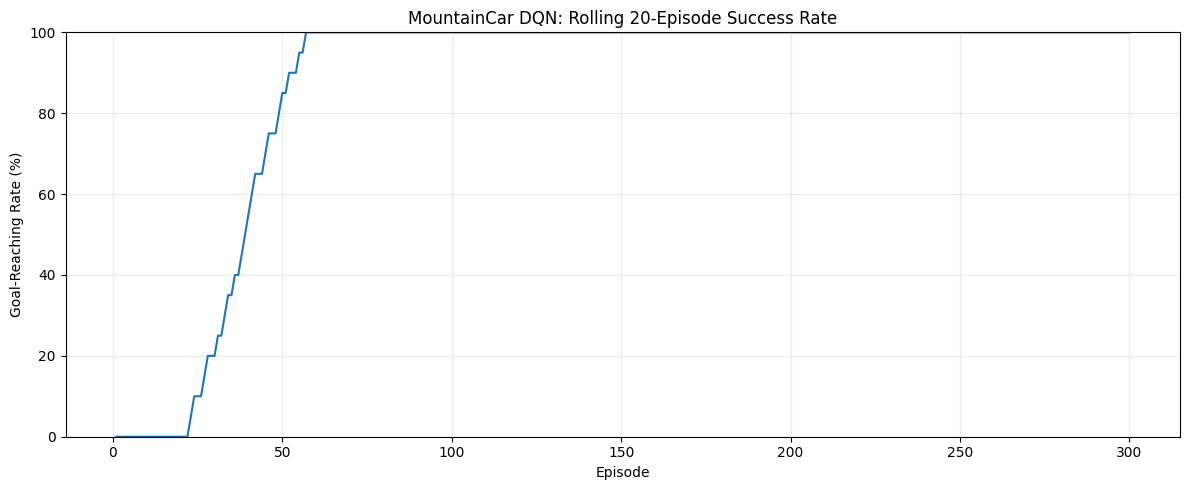

In [14]:
success_rate = (
    history_df[
        "goal_reached"
    ]
    .rolling(
        20,
        min_periods=1,
    )
    .mean()
    * 100
)

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    history_df["episode"],
    success_rate,
)

plt.xlabel("Episode")
plt.ylabel(
    "Goal-Reaching Rate (%)"
)
plt.title(
    "MountainCar DQN: "
    "Rolling 20-Episode Success Rate"
)
plt.ylim(
    0,
    100,
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 26. Epsilon

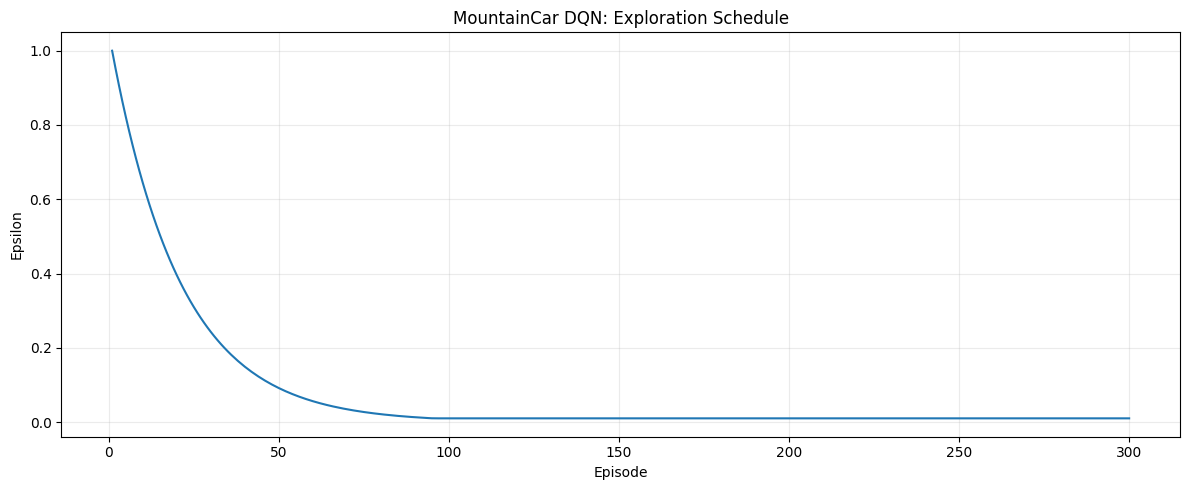

In [15]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    history_df["episode"],
    history_df["epsilon"],
)

plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title(
    "MountainCar DQN: "
    "Exploration Schedule"
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 27. Average Q-value

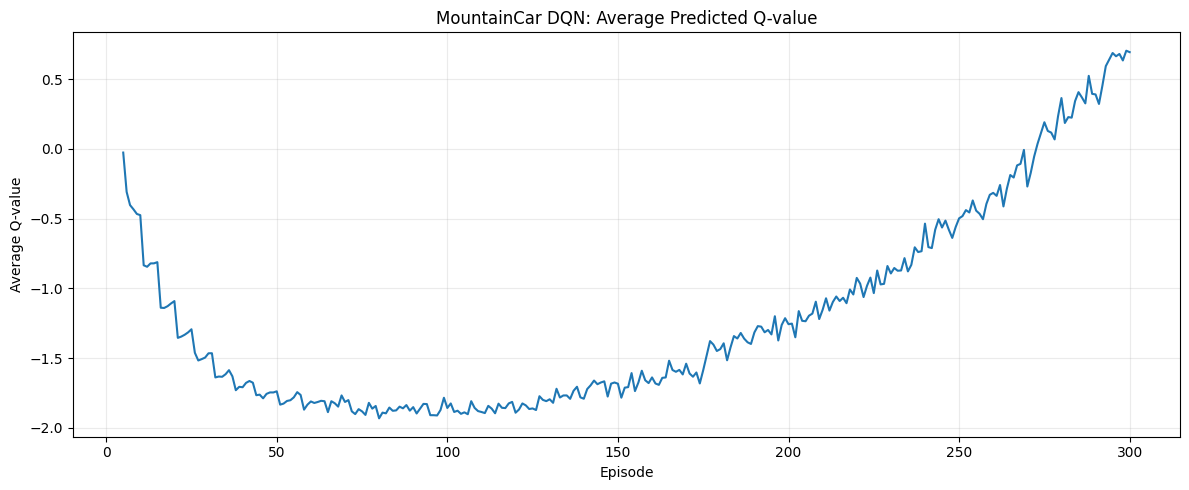

In [16]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    history_df["episode"],
    history_df["average_q"],
)

plt.xlabel("Episode")
plt.ylabel("Average Q-value")
plt.title(
    "MountainCar DQN: "
    "Average Predicted Q-value"
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 28. TD error

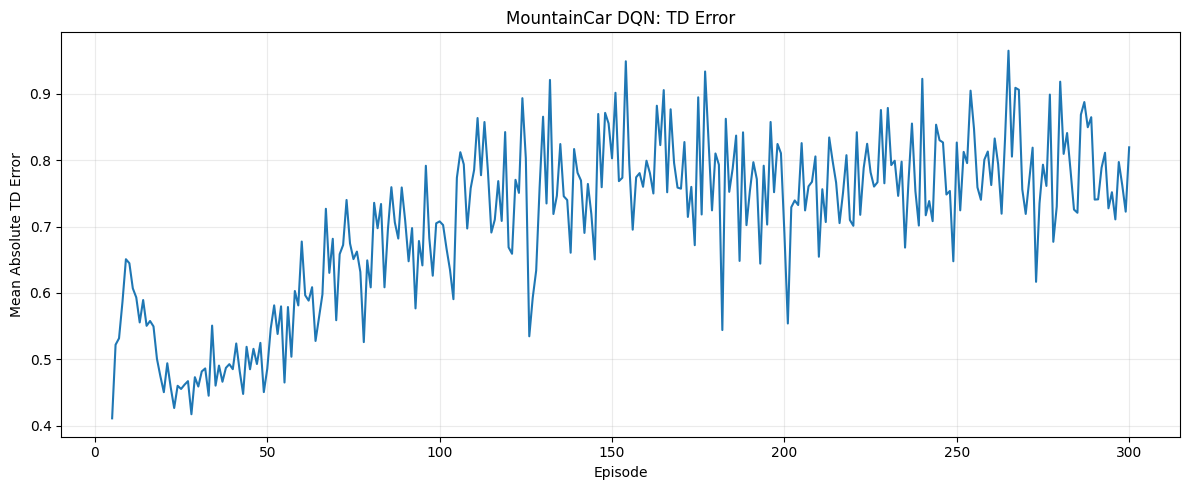

In [17]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    history_df["episode"],
    history_df["td_error"],
)

plt.xlabel("Episode")
plt.ylabel(
    "Mean Absolute TD Error"
)
plt.title(
    "MountainCar DQN: TD Error"
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 29. Training loss

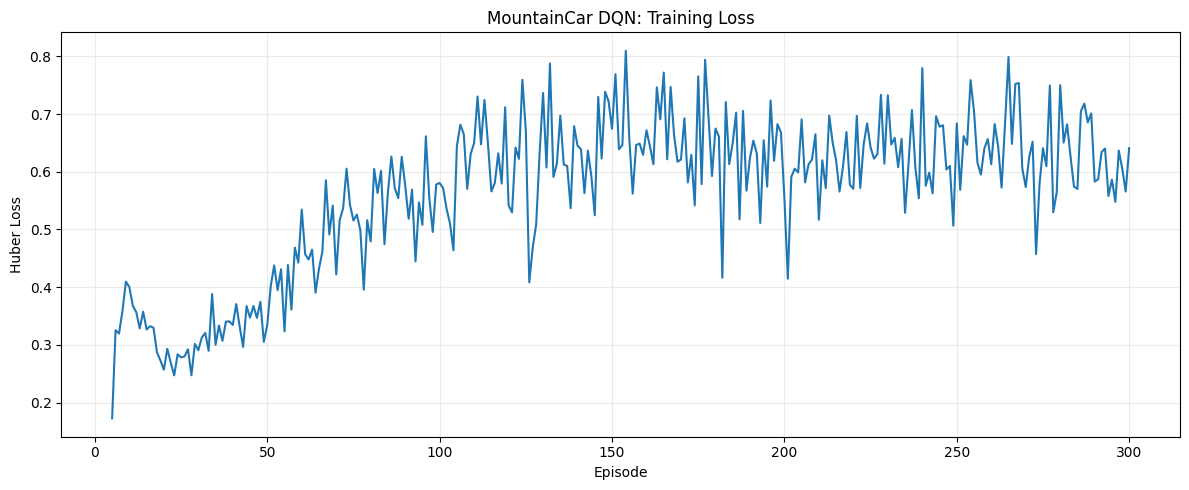

In [18]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    history_df["episode"],
    history_df["loss"],
)

plt.xlabel("Episode")
plt.ylabel("Huber Loss")
plt.title(
    "MountainCar DQN: "
    "Training Loss"
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 30. Random-policy baseline

In [19]:
def evaluate_random_policy(
    episodes=20,
    seed=20_000,
):
    env = MountainCarEnvironment(
        gym.make(
            "MountainCar-v0"
        )
    )

    records = []

    for episode in range(
        episodes
    ):
        state, info = env.reset(
            seed=seed + episode
        )

        done = False
        total_reward = 0.0
        steps = 0
        goal_reached = False
        max_position = state[0]

        while not done:
            action = (
                env.action_space.sample()
            )

            (
                state,
                reward,
                terminated,
                truncated,
                info,
            ) = env.step(action)

            done = (
                terminated
                or truncated
            )

            total_reward += reward
            steps += 1

            max_position = max(
                max_position,
                state[0],
            )

            goal_reached = (
                goal_reached
                or info.get(
                    "goal_reached",
                    False,
                )
            )

        records.append(
            {
                "episode": episode + 1,
                "total_reward": total_reward,
                "episode_length": steps,
                "goal_reached": goal_reached,
                "max_position": max_position,
            }
        )

    env.close()

    return pd.DataFrame(
        records
    )


random_eval_df = (
    evaluate_random_policy()
)

display(
    random_eval_df
)

print(
    "Random mean custom reward:",
    random_eval_df[
        "total_reward"
    ].mean(),
)

print(
    "Random success rate:",
    f'{100 * random_eval_df["goal_reached"].mean():.1f}%',
)

,episode,total_reward,episode_length,goal_reached,max_position
0,1,-146.1802,200,False,-0.4447
1,2,-92.5383,200,False,-0.3001
2,3,-136.0763,200,False,-0.4189
3,4,-104.8053,200,False,-0.3595
4,5,-87.5860,200,False,-0.3921
5,6,-189.9921,200,False,-0.3652
6,7,-131.6119,200,False,-0.4045
7,8,-85.9069,200,False,-0.3712
8,9,-96.1838,200,False,-0.3828
9,10,-101.9033,200,False,-0.4044


Random mean custom reward: -128.03183025885374
Random success rate: 0.0%


## 31. Greedy evaluation of the trained DQN

In [20]:
def evaluate_agent(
    agent,
    episodes=20,
    seed=30_000,
):
    env = MountainCarEnvironment(
        gym.make(
            "MountainCar-v0"
        )
    )

    records = []

    for episode in range(
        episodes
    ):
        state, info = env.reset(
            seed=seed + episode
        )

        done = False
        total_reward = 0.0
        steps = 0
        goal_reached = False
        max_position = state[0]

        while not done:
            action = agent.select_action(
                state,
                training=False,
            )

            (
                state,
                reward,
                terminated,
                truncated,
                info,
            ) = env.step(action)

            done = (
                terminated
                or truncated
            )

            total_reward += reward
            steps += 1

            max_position = max(
                max_position,
                state[0],
            )

            goal_reached = (
                goal_reached
                or info.get(
                    "goal_reached",
                    False,
                )
            )

        records.append(
            {
                "episode": episode + 1,
                "total_reward": total_reward,
                "episode_length": steps,
                "goal_reached": goal_reached,
                "max_position": max_position,
            }
        )

    env.close()

    return pd.DataFrame(
        records
    )


evaluation_df = evaluate_agent(
    agent,
    episodes=20,
)

display(
    evaluation_df
)

print(
    "Mean custom reward:",
    evaluation_df[
        "total_reward"
    ].mean(),
)

print(
    "Reward SD:",
    evaluation_df[
        "total_reward"
    ].std(),
)

print(
    "Mean episode length:",
    evaluation_df[
        "episode_length"
    ].mean(),
)

print(
    "Goal-reaching rate:",
    f'{100 * evaluation_df["goal_reached"].mean():.1f}%',
)

print(
    "Mean maximum position:",
    evaluation_df[
        "max_position"
    ].mean(),
)

,episode,total_reward,episode_length,goal_reached,max_position
0,1,67.6500,136,True,0.5474
1,2,65.2300,137,True,0.5474
2,3,63.3617,137,True,0.5474
3,4,59.5745,186,True,0.5474
4,5,55.1734,137,True,0.5474
5,6,67.6495,136,True,0.5474
6,7,64.6552,139,True,0.5372
7,8,71.3032,148,True,0.5474
8,9,64.1307,181,True,0.5474
9,10,65.0816,136,True,0.5474


Mean custom reward: 66.72703389463877
Reward SD: 6.330614049179829
Mean episode length: 145.6
Goal-reaching rate: 100.0%
Mean maximum position: 0.54475725


## 32. Random policy versus trained DQN

In [21]:
comparison_df = pd.DataFrame(
    {
        "Policy": [
            "Random",
            "Trained DQN",
        ],
        "Mean Custom Reward": [
            random_eval_df[
                "total_reward"
            ].mean(),
            evaluation_df[
                "total_reward"
            ].mean(),
        ],
        "Goal Rate (%)": [
            100
            * random_eval_df[
                "goal_reached"
            ].mean(),
            100
            * evaluation_df[
                "goal_reached"
            ].mean(),
        ],
        "Mean Max Position": [
            random_eval_df[
                "max_position"
            ].mean(),
            evaluation_df[
                "max_position"
            ].mean(),
        ],
    }
)

display(
    comparison_df
)

,Policy,Mean Custom Reward,Goal Rate (%),Mean Max Position
0,Random,-128.0318,0.0,-0.3949
1,Trained DQN,66.7270,100.0,0.5448


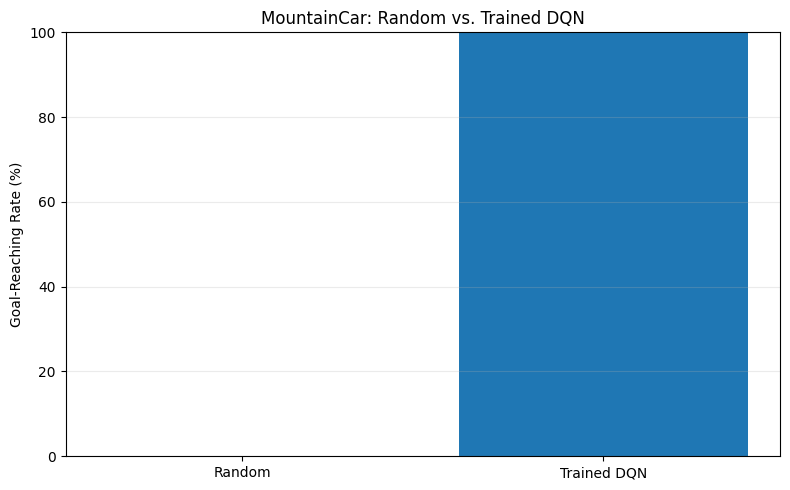

In [22]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    comparison_df["Policy"],
    comparison_df[
        "Goal Rate (%)"
    ],
)

plt.ylabel(
    "Goal-Reaching Rate (%)"
)

plt.title(
    "MountainCar: "
    "Random vs. Trained DQN"
)

plt.ylim(
    0,
    100,
)

plt.grid(
    axis="y",
    alpha=0.25,
)

plt.tight_layout()
plt.show()

## 33. Visualize the learned policy over the state space

The state has only two dimensions, so we can evaluate the learned greedy action on a grid of positions and velocities.

For every grid point:

$$
\pi(s)
=
\arg\max_aQ(s,a;\theta).
$$

The resulting plot shows which action the DQN prefers in each part of the state space.

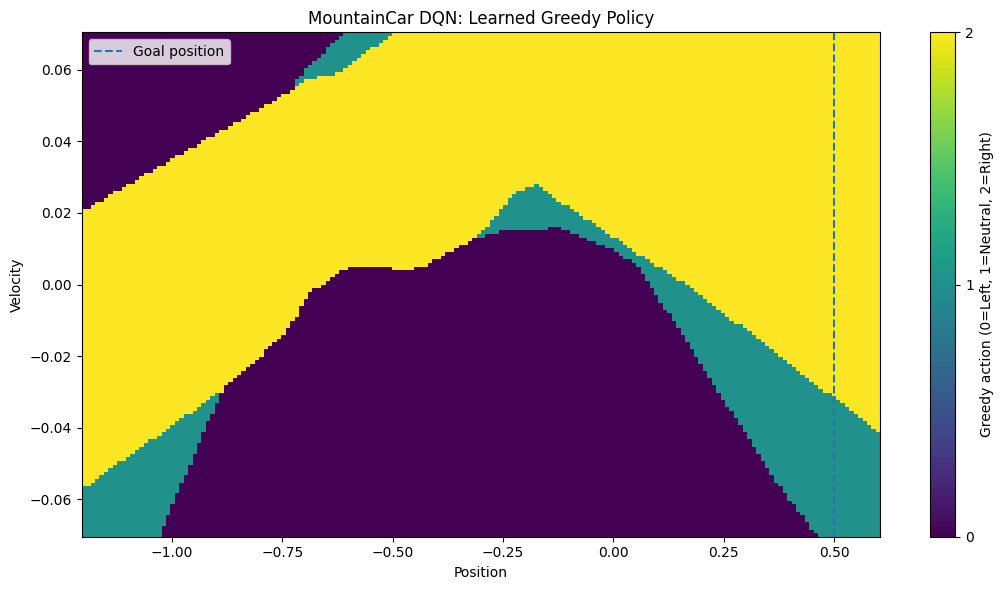

In [23]:
positions = np.linspace(
    -1.2,
    0.6,
    180,
)

velocities = np.linspace(
    -0.07,
    0.07,
    140,
)

P_grid, V_grid = np.meshgrid(
    positions,
    velocities,
)

states_grid = np.column_stack(
    [
        P_grid.ravel(),
        V_grid.ravel(),
    ]
).astype(
    np.float32
)

q_grid = agent.q_network(
    states_grid,
    training=False,
).numpy()

policy_grid = np.argmax(
    q_grid,
    axis=1,
).reshape(
    V_grid.shape
)

plt.figure(
    figsize=(11, 6)
)

mesh = plt.pcolormesh(
    P_grid,
    V_grid,
    policy_grid,
    shading="auto",
)

plt.colorbar(
    mesh,
    ticks=[0, 1, 2],
    label=(
        "Greedy action "
        "(0=Left, 1=Neutral, 2=Right)"
    ),
)

plt.axvline(
    0.5,
    linestyle="--",
    label="Goal position",
)

plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title(
    "MountainCar DQN: "
    "Learned Greedy Policy"
)
plt.legend()
plt.tight_layout()
plt.show()

## 34. Inspect Q-values for one state

In [24]:
inspect_state = np.array(
    [-0.50, 0.02],
    dtype=np.float32,
)

q_values = agent.q_network(
    inspect_state[None, :],
    training=False,
).numpy()[0]

action_names = {
    0: "Accelerate left",
    1: "No acceleration",
    2: "Accelerate right",
}

best_action = int(
    np.argmax(
        q_values
    )
)

print(
    "State:",
    inspect_state,
)

print()

for action, q_value in enumerate(
    q_values
):
    print(
        f"Action {action}: "
        f"Q = {q_value:9.4f} | "
        f"{action_names[action]}"
    )

print(
    "\nGreedy action:",
    best_action,
    "->",
    action_names[
        best_action
    ],
)

State: [-0.5   0.02]

Action 0: Q =   -3.6158 | Accelerate left
Action 1: Q =   -3.2710 | No acceleration
Action 2: Q =   -2.6758 | Accelerate right

Greedy action: 2 -> Accelerate right


## 35. Save and reload the agent

In [25]:
agent.save(
    AGENT_PATH
)

loaded_agent = DQNAgent(
    learning_rate=0.001,
    gamma=0.99,
    replay_size=100_000,
    min_replay_size=1_000,
    epsilon=1.0,
    min_epsilon=0.01,
    epsilon_decay=1.05,
    target_update_steps=1_000,
)

loaded_agent.load(
    AGENT_PATH
)

print(
    "Restored epsilon:",
    loaded_agent.epsilon,
)

print(
    "Restored environment steps:",
    loaded_agent.environment_steps,
)

print(
    "Restored gradient steps:",
    loaded_agent.gradient_steps,
)

Restored epsilon: 0.01
Restored environment steps: 43111
Restored gradient steps: 42112


## 36. Record a greedy evaluation episode

In [26]:
def record_episode(
    agent,
    filename=(
        "mountain_car_dqn.mp4"
    ),
    seed=40_000,
    fps=30,
):
    env = MountainCarEnvironment(
        gym.make(
            "MountainCar-v0",
            render_mode="rgb_array",
        )
    )

    state, info = env.reset(
        seed=seed
    )

    frames = [
        env.render()
    ]

    done = False
    total_reward = 0.0
    episode_length = 0
    goal_reached = False

    while not done:
        action = agent.select_action(
            state,
            training=False,
        )

        (
            state,
            reward,
            terminated,
            truncated,
            info,
        ) = env.step(
            action
        )

        done = (
            terminated
            or truncated
        )

        frames.append(
            env.render()
        )

        total_reward += reward
        episode_length += 1

        goal_reached = (
            goal_reached
            or info.get(
                "goal_reached",
                False,
            )
        )

    env.close()

    imageio.mimsave(
        filename,
        frames,
        fps=fps,
    )

    print(
        "Video saved:",
        filename,
    )

    print(
        "Custom reward:",
        total_reward,
    )

    print(
        "Episode length:",
        episode_length,
    )

    print(
        "Goal reached:",
        goal_reached,
    )

    return filename


video_file = record_episode(
    agent
)

display(
    Video(
        video_file,
        embed=True,
    )
)

Video saved: mountain_car_dqn.mp4
Custom reward: 69.00371315817938
Episode length: 147
Goal reached: True


## 37. Original project code versus this portfolio implementation

| Original component | Portfolio notebook |
|---|---|
| `MountainCarEnvironment(GymEnvironment)` | `MountainCarEnvironment(gym.Wrapper)` |
| `DeepQLearning` | `DQNAgent` |
| `Agent` | `DQNAgent` |
| hidden replay memory | `ReplayBuffer` |
| Q network | explicit TensorFlow model |
| hidden target network | `target_network` |
| `AverageQMetric` | `history["average_q"]` |
| `ExplorationTrackerMetric` | `history["epsilon"]` |
| `AbsoluteValueErrorMetric` | `history["td_error"]` |
| `TotalRewardMetric` | `history["total_reward"]` |
| `EpisodeLengthMetric` | `history["episode_length"]` |
| `Plotter` | Matplotlib plots |
| `agent.save()` | `DQNAgent.save()` |
| `agent.load()` | `DQNAgent.load()` |
| `LiveEpisodeViewer` | embedded Colab video |
| `VideoEpisodeSaver` | `record_episode()` |

The custom reward itself is preserved exactly in meaning.

## 38. DQN algorithm

```text
Input:
    MountainCar environment
    online Q-network Q(s,a;theta)
    target Q-network Q(s,a;theta-)
    replay memory D
    discount factor gamma
    exploration epsilon

Initialize:
    theta randomly
    theta- = theta
    D = empty

For each episode:

    Reset environment
    Observe state S

    Repeat until terminal:

        1. Select action using epsilon-greedy

           With probability epsilon:
               choose random action A

           Otherwise:
               A = argmax_a Q(S,a;theta)

        2. Execute A

           Observe next state S'
           Calculate custom reward R
           Observe done

        3. Store transition

           (S,A,R,S',done)

           in replay memory D

        4. Sample random mini-batch

        5. Compute target

           Y =
               R
               + gamma(1-done)
                 max_a' Q(S',a';theta-)

        6. Get current prediction

           Q_pred = Q(S,A;theta)

        7. Update online network

           Minimize:
               Loss(Y,Q_pred)

        8. Periodically copy

           theta- <- theta

        9. S <- S'

    Decay epsilon

Output:
    trained Q-network
```

## 39. Complete learning flow

$$
\boxed{
S_t
\rightarrow
Q(S_t,\cdot;\theta)
\rightarrow
A_t
\rightarrow
S_{t+1}
\rightarrow
R_{t+1}^{\text{custom}}
\rightarrow
\mathcal D
\rightarrow
Y_t
\rightarrow
\delta_t
\rightarrow
\theta\text{ update}
}
$$

The custom reward changes the learning signal, but the underlying DQN update remains the same.

The neural network still approximates the action-value function:

$$
\boxed{
Q(s,a;\theta)
}
$$

and the greedy policy remains

$$
\boxed{
\pi(s)=\arg\max_aQ(s,a;\theta).
}
$$

## 40. Portfolio interpretation

This project demonstrates:

- custom reward shaping,
- continuous-state reinforcement learning,
- discrete-action control,
- neural-network Q-function approximation,
- off-policy learning,
- epsilon-greedy exploration,
- experience replay,
- target-network stabilization,
- TD learning,
- model checkpointing,
- quantitative policy evaluation,
- state-space policy visualization,
- and simulation video generation.

For the final portfolio discussion, report more than the custom reward. The most interpretable MountainCar results are:

- **goal-reaching rate**,
- **average episode length**,
- **maximum position reached**,
- and the greedy-policy behavior over the position-velocity state space.

## References

1. Mnih, V., Kavukcuoglu, K., Silver, D., et al. (2015). **Human-level control through deep reinforcement learning.** *Nature*, 518, 529–533.

2. Gymnasium documentation: **Mountain Car**. https://gymnasium.farama.org/environments/classic_control/mountain_car/

3. Gymnasium documentation: **Basic Usage**. https://gymnasium.farama.org/introduction/basic_usage/